--- Exercise 1: Binary Classification Objectives ---
Logistic AUC: 0.9908
Logitraw AUC: 0.9581

--- Exercise 2: Tracking Business Metrics ---


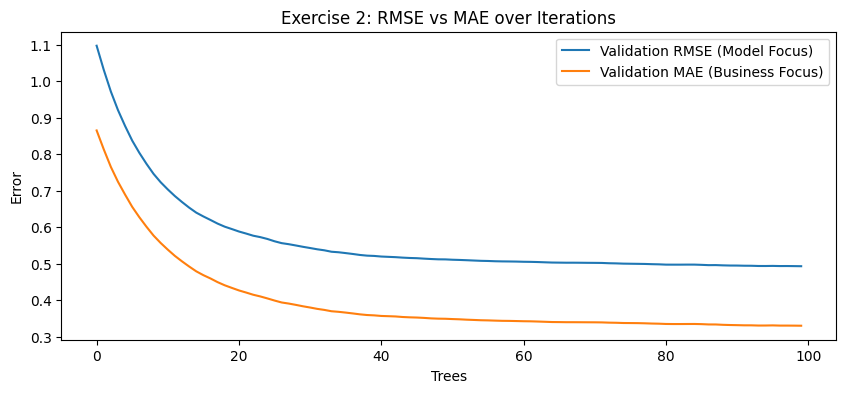


--- Exercise 3: Count Data (Poisson vs Tweedie) ---
MSE MAE: 2.1018 | Min Prediction: 0.74
Poisson MAE: 2.0044 | Min Prediction: 0.66
Tweedie MAE: 2.0337 | Min Prediction: 0.23

--- Exercises 4 & 5: Custom Blended Objective & MAPE Metric ---
[0]	train-MAPE:59.40896	validation-MAPE:59.58079
[20]	train-MAPE:24.70600	validation-MAPE:25.13102
[40]	train-MAPE:21.21624	validation-MAPE:22.24915
[60]	train-MAPE:19.54102	validation-MAPE:20.91987
[80]	train-MAPE:18.69183	validation-MAPE:20.34616
[99]	train-MAPE:18.00964	validation-MAPE:19.92912

Target Variance: 1.3800
Prediction Variance: 1.0891
Variance Ratio (Goal is ~1.0): 0.7892


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Exercise 1: Explore Standard Objectives
# ==========================================
print("--- Exercise 1: Binary Classification Objectives ---")
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

# Model 1: Standard Logistic
model_log = xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42)
model_log.fit(X_train_c, y_train_c)
preds_log = model_log.predict_proba(X_test_c)[:, 1]

# Model 2: Logitraw (outputs raw log-odds instead of probabilities)
model_raw = xgb.XGBClassifier(objective="binary:logitraw", eval_metric=["auc", "error"], random_state=42)
model_raw.fit(X_train_c, y_train_c)
# We apply the sigmoid function manually to convert raw log-odds back to probabilities
preds_raw = 1 / (1 + np.exp(-model_raw.predict(X_test_c)))

print(f"Logistic AUC: {roc_auc_score(y_test_c, preds_log):.4f}")
print(f"Logitraw AUC: {roc_auc_score(y_test_c, preds_raw):.4f}")

# ==========================================
# Exercise 2: Choosing a Business Metric
# ==========================================
print("\n--- Exercise 2: Tracking Business Metrics ---")
cali = fetch_california_housing()
X_reg, y_reg = cali.data, cali.target
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_train_r, y_train_r, test_size=0.2, random_state=42)

# NEW FIX: eval_metric is now passed directly into XGBRegressor!
reg = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    objective="reg:squarederror", 
    random_state=42,
    eval_metric=["rmse", "mae"] 
)

# Fit method no longer contains eval_metric
reg.fit(
    X_train_r, y_train_r, 
    eval_set=[(X_train_r, y_train_r), (X_val_r, y_val_r)], 
    verbose=False
)

results = reg.evals_result()
plt.figure(figsize=(10, 4))
plt.plot(results['validation_1']['rmse'], label='Validation RMSE (Model Focus)')
plt.plot(results['validation_1']['mae'], label='Validation MAE (Business Focus)')
plt.title("Exercise 2: RMSE vs MAE over Iterations")
plt.xlabel("Trees")
plt.ylabel("Error")
plt.legend()
plt.show()

# ==========================================
# Exercise 3: Poisson and Tweedie Objectives
# ==========================================
print("\n--- Exercise 3: Count Data (Poisson vs Tweedie) ---")
# Generate synthetic count data (e.g., website visits)
np.random.seed(42)
X_count = np.random.rand(1000, 5)
# True relationship is exponential to ensure positive counts
y_count = np.random.poisson(lam=np.exp(X_count[:, 0] * 2 + X_count[:, 1])) 
X_train_ct, X_test_ct, y_train_ct, y_test_ct = train_test_split(X_count, y_count, test_size=0.2, random_state=42)

models_ct = {
    "MSE": xgb.XGBRegressor(objective="reg:squarederror", random_state=42),
    "Poisson": xgb.XGBRegressor(objective="count:poisson", random_state=42), # Imposes exponential transform
    "Tweedie": xgb.XGBRegressor(objective="reg:tweedie", tweedie_variance_power=1.3, random_state=42) # Between Poisson and Gamma
}

for name, model in models_ct.items():
    model.fit(X_train_ct, y_train_ct)
    preds = model.predict(X_test_ct)
    mae = mean_absolute_error(y_test_ct, preds)
    print(f"{name} MAE: {mae:.4f} | Min Prediction: {preds.min():.2f}")

# ==========================================
# Exercises 4 & 5: Custom Objective & Custom Metric
# ==========================================
print("\n--- Exercises 4 & 5: Custom Blended Objective & MAPE Metric ---")

# Setup DMatrix (Required for custom objectives via xgb.train)
dtrain = xgb.DMatrix(X_train_r, label=y_train_r)
dval = xgb.DMatrix(X_val_r, label=y_val_r)
sigma_y2 = np.var(y_train_r)

# Custom Objective: Blend MSE with Variance Matching
def blended_objective(preds, dtrain, lam=0.5):
    labels = dtrain.get_label()
    n = preds.size
    mean_pred = np.mean(preds)
    var_pred = np.mean((preds - mean_pred) ** 2)
    
    # Variance Gradient & Hessian
    grad_var = (4.0 / n) * (var_pred - sigma_y2) * (preds - mean_pred)
    hess_var = np.full_like(preds, 4.0 / n)
    
    # MSE Gradient & Hessian
    grad_mse = preds - labels
    hess_mse = np.ones_like(preds)
    
    return grad_mse + lam * grad_var, hess_mse + lam * hess_var

# Custom Metric: MAPE (Mean Absolute Percentage Error)
def custom_mape(preds, dtrain):
    labels = dtrain.get_label()
    # Avoid division by zero
    mape = np.mean(np.abs((labels - preds) / (labels + 1e-8))) * 100
    return "MAPE", mape

params = {
    "max_depth": 4,
    "eta": 0.1,
    "disable_default_eval_metric": 1 # We want to strictly see our custom metric
}

# Train using the custom objective and metric
# NEW FIX: Changed `feval` to `custom_metric` to support XGBoost 2.0+
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    obj=blended_objective,
    custom_metric=custom_mape, 
    evals=[(dtrain, "train"), (dval, "validation")],
    verbose_eval=20 # Print every 20 rounds
)

# Check the final Variance Ratio
final_preds = bst.predict(dval)
print(f"\nTarget Variance: {np.var(y_val_r):.4f}")
print(f"Prediction Variance: {np.var(final_preds):.4f}")
print(f"Variance Ratio (Goal is ~1.0): {np.var(final_preds) / np.var(y_val_r):.4f}")